# HW3 - Neural Network Model of BTS Data

In this module, I use the BTS data to train a Neural Net and classify whether a flight will be dalayed(by more than 15 minutes) 

Problem Statement:(Similar to HW2 except the NN part)
The objective of this analysis is to train a Neural Network build and compare it against a clasification model(I have used KNN) on real-world data from the BTS which predict whether a flight will be delayed at arrival.
A flight is defined to be delayed if it arrives more than 15 minutes past its due arival time at the destination airport. This may be constructed as a binary response variable as:
Y=1 if the flight is delayed and 
Y=0 if the flight is not delayed.
The predictors used for this model are:
1. DEP_DELAY: departure delay in minutes,
2. AIR_TIME: flight time in minutes,
3. DISTANCE: flight distance.

The response variable is the binary arrival-delay indicator constructed from ARR_DELAY(Arrival Delay).
The original dataset contains 544,003 flight observations. After removing observations containing missing values in ARR_DELAY, DEP_DELAY, AIR_TIME, or DISTANCE, 517,222 observations remain for the analysis. 

Goal: The goal is to compare a Neural Network vs a classification methods(I have used KNN with k=5) in their ability to predict whether an arriving flight will be delayed.

In [ ]:
# YOUR CODE HERE - you can create as many additional Markdown or Code cells as needed
# Suman's code
import pandas as pd
import torch
from torch import nn
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import ConfusionMatrixDisplay
df=pd.read_csv("T_ONTIME_REPORTING.csv")
SEED=42
# Using the same dataset from HW2 and HW1
data=df[["ARR_DELAY", "DEP_DELAY", "AIR_TIME", "DISTANCE"]].dropna() # so that empty values are rejected
y = (data['ARR_DELAY'] >= 15).astype(int)
X = data[['DEP_DELAY', 'AIR_TIME', 'DISTANCE']]

Split the datset into traning and testing datasets for both KNN and the Neural Net and scale it accordingly.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)
scaler = StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test) 

Time to train the NN!
Analysis of the NN: 
The Neural Network I have trained consists of 4 layers, the first has 3 inputs(DEP_DELAY, AIR_TIME and DISTANCE) which maps to 32 nodes in the 2nd layer(Parameters=3*32+32=128) which is then mapped to 16 nodes in the 3rd layer(Parameters=16*32+16=528) and finally converges to 1 single output(Parameters=1*16+1=17) in the last layer, which gives the model a total of 673 parameters. The ReLU(Rectified Learning Unit) layers are activation functions in the form f(x)=max(0,x) to introduce non-linearity otherwise, the layers would just be equal to a single linear layer.

Epoch 10: train loss = 0.1631, validation loss = 0.1633
Epoch 20: train loss = 0.1470, validation loss = 0.1472
Epoch 30: train loss = 0.1372, validation loss = 0.1371
Epoch 40: train loss = 0.1311, validation loss = 0.1305
Epoch 50: train loss = 0.1261, validation loss = 0.1253
Epoch 60: train loss = 0.1218, validation loss = 0.1210
Epoch 70: train loss = 0.1181, validation loss = 0.1173
Epoch 80: train loss = 0.1144, validation loss = 0.1137
Epoch 90: train loss = 0.1105, validation loss = 0.1099
Epoch 100: train loss = 0.1065, validation loss = 0.1059
Epoch 110: train loss = 0.1022, validation loss = 0.1018
Epoch 120: train loss = 0.0978, validation loss = 0.0974
Epoch 130: train loss = 0.0933, validation loss = 0.0930
Epoch 140: train loss = 0.0889, validation loss = 0.0886
Epoch 150: train loss = 0.0846, validation loss = 0.0844
Epoch 160: train loss = 0.0807, validation loss = 0.0805
Epoch 170: train loss = 0.0772, validation loss = 0.0770
Epoch 180: train loss = 0.0744, validati

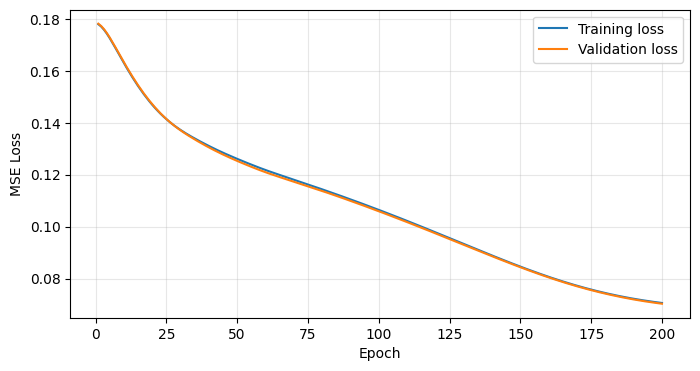

In [25]:
torch.manual_seed(SEED)
device = torch.device("mps")
# Convert the data to float32 tensors.
data = torch.tensor(np.asarray(X_train), dtype=torch.float32, device=device)
labels = torch.tensor(np.asarray(y_train), dtype=torch.float32, device=device).view(-1, 1)
val_data = torch.tensor(np.asarray(X_val), dtype=torch.float32, device=device)
val_labels = torch.tensor(np.asarray(y_val), dtype=torch.float32, device=device).view(-1, 1)
net = nn.Sequential(nn.Linear(3, 32),nn.ReLU(),nn.Linear(32, 16),nn.ReLU(),nn.Linear(16, 1)).to(device)
optim = torch.optim.SGD(net.parameters(), lr=1e-2, momentum=0.9)
criterion = nn.MSELoss()
loss_history = []
val_loss_history = []
for epoch in range(200):
    net.train()
    optim.zero_grad()
    prediction = net(data)
    loss = criterion(prediction, labels)
    loss.backward()
    optim.step()
    net.eval()
    # now use the .item() to record the data
    with torch.no_grad():
        train_loss = criterion(net(data), labels).item()
        val_loss = criterion(net(val_data), val_labels).item()

    loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1}: "
            f"train loss = {train_loss:.4f}, "
            f"validation loss = {val_loss:.4f}"
        )

history = pd.DataFrame({
    "epoch": range(1, 201),
    "train_loss": loss_history,
    "val_loss": val_loss_history
})
plt.figure(figsize=(8, 4))
plt.plot(history["epoch"], loss_history, label="Training loss")
plt.plot(history["epoch"], val_loss_history, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Analysis of traning error:
The traning MSE loss decreases from 0.16 at Epoch 10 to 0.07 at Epoch 200 as weights get fine-tuned via backpropagation. The rate of decrease of the loss decreases at higher epochs suggests the convergence of the network to the target data.


Analysis of KNN model: 
The KNN model is a classification method which classifies data into a class based on the euclidean distance of that data point from 'k' of its nearest neighbours and then classifies it according to a majority. Here I have used k=5 to account for the bias-variance tradeoff.

<Figure size 600x600 with 0 Axes>

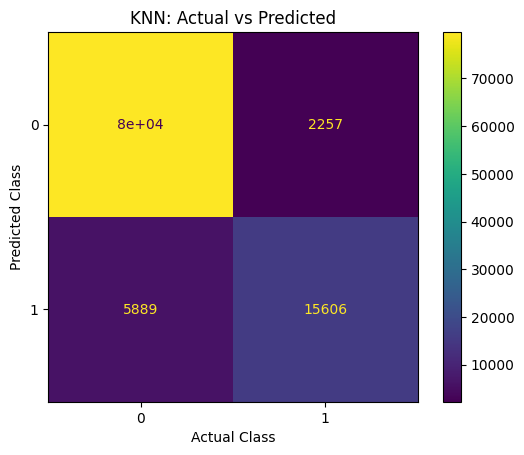

In [26]:
model=KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)
plt.figure(figsize=(6, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_predicted
) # A confusion matrix is useful as a plot would simply have overlaps at 4 points
plt.xlabel("Actual Class")
plt.ylabel("Predicted Class")
plt.title("KNN: Actual vs Predicted")
plt.xticks([0, 1])
plt.yticks([0, 1])
plt.show()

Time to test NN vs KNN

In [27]:
net.eval()
with torch.no_grad():
    test_data = torch.tensor(np.asarray(X_test), dtype=torch.float32, device=device)
    test_scores = net(test_data).cpu().numpy().ravel()
test_predictions = (test_scores >= 0.5).astype(int)
nn_test_error = np.mean(test_predictions != np.asarray(y_test).ravel())
print(f"Test classification error for NN: {nn_test_error:.2%}")

y_predicted=model.predict(X_test)
knn_test_error = np.mean(y_predicted != np.asarray(y_test).ravel())
print(f"Test classification error for KNN: {knn_test_error:.2%}")

Test classification error for NN: 8.30%
Test classification error for KNN: 7.87%


Analysis of Results:
The NN has a test error of 8.30% while KNN has a test error of 7.37% which suggests accuracies of 91.70% and 92.13% respectively. The KNN does slightly better than the NN in this case but however, the accuracy of the NN is expected to increase(it shouldn't be too significant) with more traning as the loss was still decreasing at epoch 200.